**code generated by Chatgpt**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [2]:
# 1. 定義 Runge function f(x) 和它的導數 f'(x)
def runge_function(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def runge_derivative(x):
    # f'(x) = -50x / (1+25x^2)^2
    return (-50.0 * x) / (1.0 + 25.0 * x**2)**2

In [3]:
# 2. 產生資料
np.random.seed(42)
x_all = np.random.uniform(-1, 1, 500).reshape(-1, 1)   # shape (500,1)
y_all = runge_function(x_all)                          # f(x)
yprime_all = runge_derivative(x_all)                   # f'(x)

# 切 train / val
x_train, x_val, y_train, y_val, yprime_train, yprime_val = train_test_split(
    x_all, y_all, yprime_all, test_size=0.2, random_state=42
)


In [4]:
# 3. 建立神經網路模型 (仍然只輸出 f_hat(x))
base_model = keras.Sequential([
    layers.Dense(64, activation="tanh", input_shape=(1,)),
    layers.Dense(64, activation="tanh"),
    layers.Dense(1)   # 預測 f(x)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# 4. 自訂一個 Model class，讓它同時計算 derivative loss
class RungeModel(keras.Model):
    def __init__(self, base):
        super().__init__()
        self.base = base  # 剛剛的 sequential

    def call(self, x):
        return self.base(x)

    # 自訂訓練步驟
    def train_step(self, data):
        # data 是 (inputs, targets)
        # 需要同時拿到 y_true (f) 和 yprime_true (f')
        x_batch, (y_true, yprime_true) = data

        with tf.GradientTape() as tape_total:
            tape_total.watch(x_batch)  # 之後要對 x 求導
            y_pred = self.base(x_batch)  # NN 對 f(x) 的預測, shape (batch,1)

            # 使用 GradientTape 再包一層來求 dy_pred/dx
            with tf.GradientTape() as tape_deriv:
                tape_deriv.watch(x_batch)
                y_pred_inner = self.base(x_batch)
            yprime_pred = tape_deriv.gradient(y_pred_inner, x_batch)  # df_hat/dx

            # function loss: (f_true - f_pred)^2
            func_loss = tf.reduce_mean(tf.square(y_true - y_pred))

            # derivative loss: (f'_true - f'_pred)^2
            deriv_loss = tf.reduce_mean(tf.square(yprime_true - yprime_pred))

            total_loss = func_loss + deriv_loss

        # 反向傳遞 + 更新權重
        grads = tape_total.gradient(total_loss, self.base.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.base.trainable_variables))

        # 要回報的 metrics
        return {
            "loss": total_loss,
            "func_loss": func_loss,
            "deriv_loss": deriv_loss,
        }

    # 自訂驗證步驟 (不更新權重)
    def test_step(self, data):
        x_batch, (y_true, yprime_true) = data

        with tf.GradientTape() as tape_deriv:
            tape_deriv.watch(x_batch)
            y_pred = self.base(x_batch)
        yprime_pred = tape_deriv.gradient(y_pred, x_batch)

        func_loss = tf.reduce_mean(tf.square(y_true - y_pred))
        deriv_loss = tf.reduce_mean(tf.square(yprime_true - yprime_pred))
        total_loss = func_loss + deriv_loss

        return {
            "loss": total_loss,
            "func_loss": func_loss,
            "deriv_loss": deriv_loss,
        }

# 建立這個可訓練模型
model = RungeModel(base_model)

# 指定 optimizer
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))


In [6]:

# 5. 開始訓練
history = model.fit(
    x_train,
    (y_train, yprime_train),            # y_true 包含 f(x) 和 f'(x)
    validation_data=(x_val, (y_val, yprime_val)),
    epochs=500,
    verbose=0
)

In [7]:
# 6. 評估 (我們用 validation set)
#   a) f(x) 預測誤差
y_val_pred = model.base(x_val).numpy()
mse_f = np.mean((y_val - y_val_pred)**2)
max_err_f = np.max(np.abs(y_val - y_val_pred))

#   b) f'(x) 預測誤差 (用自動微分算出模型對 x 的導數)
x_val_tf = tf.convert_to_tensor(x_val, dtype=tf.float32)
with tf.GradientTape() as tape_eval:
    tape_eval.watch(x_val_tf)
    y_val_pred_tf = model.base(x_val_tf)
yprime_val_pred_tf = tape_eval.gradient(y_val_pred_tf, x_val_tf).numpy()

mse_fprime = np.mean((yprime_val - yprime_val_pred_tf)**2)
max_err_fprime = np.max(np.abs(yprime_val - yprime_val_pred_tf))

print(f"[Function   ] MSE: {mse_f:.6f} | Max error: {max_err_f:.6f}")
print(f"[Derivative ] MSE: {mse_fprime:.6f} | Max error: {max_err_fprime:.6f}")

[Function   ] MSE: 0.000024 | Max error: 0.008540
[Derivative ] MSE: 0.000055 | Max error: 0.022989


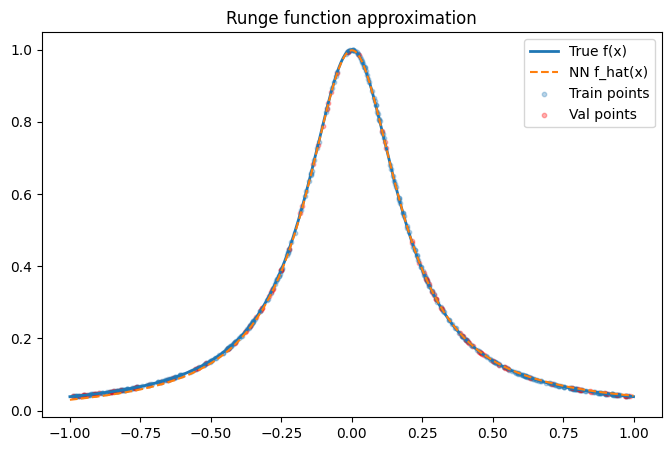

In [8]:
# 7. 畫圖：f(x) vs NN
x_grid = np.linspace(-1, 1, 500).reshape(-1, 1)
y_true = runge_function(x_grid)

y_grid_pred = model.base(x_grid).numpy()

plt.figure(figsize=(8,5))
plt.plot(x_grid, y_true, label="True f(x)", linewidth=2)
plt.plot(x_grid, y_grid_pred, label="NN f_hat(x)", linestyle="--")
plt.scatter(x_train, y_train, s=10, alpha=0.3, label="Train points")
plt.scatter(x_val, y_val, s=10, alpha=0.3, label="Val points", color="red")
plt.legend()
plt.title("Runge function approximation")
plt.show()

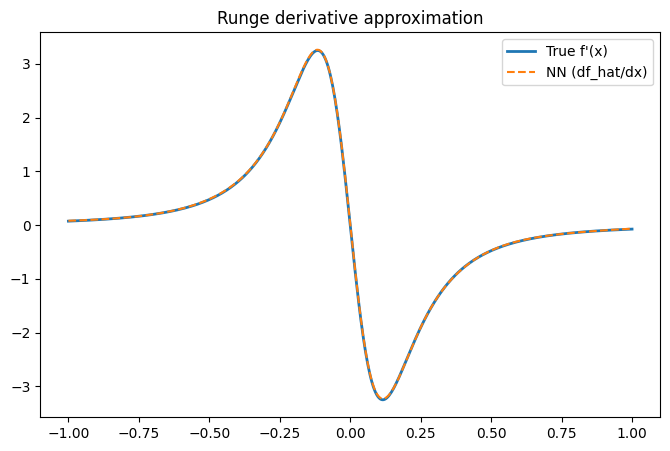

In [9]:
# 8. 畫圖：f'(x) vs NN 的導數
yprime_true = runge_derivative(x_grid)

x_grid_tf = tf.convert_to_tensor(x_grid, dtype=tf.float32)
with tf.GradientTape() as tape_grid:
    tape_grid.watch(x_grid_tf)
    y_grid_pred_tf = model.base(x_grid_tf)
yprime_grid_pred = tape_grid.gradient(y_grid_pred_tf, x_grid_tf).numpy()

plt.figure(figsize=(8,5))
plt.plot(x_grid, yprime_true, label="True f'(x)", linewidth=2)
plt.plot(x_grid, yprime_grid_pred, label="NN (df_hat/dx)", linestyle="--")
plt.legend()
plt.title("Runge derivative approximation")
plt.show()

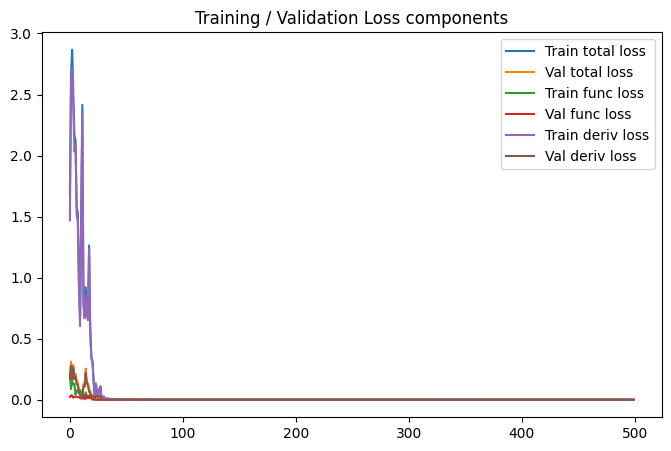

In [10]:
# 9. 畫 loss 曲線 (total / func / deriv)
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="Train total loss")
plt.plot(history.history['val_loss'], label="Val total loss")
plt.plot(history.history['func_loss'], label="Train func loss")
plt.plot(history.history['val_func_loss'], label="Val func loss")
plt.plot(history.history['deriv_loss'], label="Train deriv loss")
plt.plot(history.history['val_deriv_loss'], label="Val deriv loss")
plt.legend()
plt.title("Training / Validation Loss components")
plt.show()